In [70]:
import numpy as np, random, seaborn as sns
import torch
import matplotlib.pyplot as plt

## Полученние и обработка данных

In [71]:
def random_list(len_=100000):
  # генерация массива x: 10 000 случайных цифр от 0 до 9. Сразу в массив np.array
  x_list = [random.randint(0, 9) for _ in range(len_)]
  # target, но заполненный нулями
  y_list = [0] * len_

  # Первый элемент y равен первому элементу x
  y_list[0] = x_list[0]  # Остальные элементы y массива: y[i] = x[i] + x[0] + если y[i] >= 10, то из  y[i] вычетается 10
  for i in range(1, len_): # начинам со второго элемента т.к y[0] = x[i]
     temp_value = x_list[i] + x_list[0]
     if temp_value >= 10:
      temp_value -= 10
     y_list[i]=temp_value

  return x_list, y_list

In [72]:
x_list, y_list =  random_list()

In [73]:
"""Вероятность совпадения: при равномерном распределении вероятность того, что x[0] == 0, составляет 10 % (так как возможные значения — от 0 до 9).
Соответственно, в 90 % случаев массивы будут различаться."""
# использую метод np.array_equal с целью проверки массивов и список на идентичность. np.allclose(для массивов с плавающей точкой)
print(x_list[:20])
print(y_list[:20])
print(f'Массивы(списки) полностью идентичны: {np.array_equal(x_list, y_list)}')

[3, 2, 4, 0, 8, 2, 5, 8, 8, 5, 1, 8, 4, 2, 8, 1, 1, 5, 9, 7]
[3, 5, 7, 3, 1, 5, 8, 1, 1, 8, 4, 1, 7, 5, 1, 4, 4, 8, 2, 0]
Массивы(списки) полностью идентичны: False


In [74]:
# Разделение данных (без какого - либо смешивания)
split_idx = int(0.8 * len(x_list))
x_train, x_test = x_list[:split_idx], x_list[split_idx:]
y_train, y_test = y_list[:split_idx], y_list[split_idx:]

In [75]:
# Параметры последовательности
SEQ_LENGTH = 50 # длина последовательности

In [76]:
# Параметры последовательности
SEQ_LENGTH = 50 # длина последовательности

# функция формирования тензора последовательностей (для смещения и временных рядов, подход скользящего окна)
def sequences_(x_list, y_list, SEQ_LENGTH=50): # SEQ_LENGTH=50 продублировал
  # Списки последовательностей
  input_sequences = []
  target_sequences = []
  for i in range(len(x_list) - SEQ_LENGTH):
  # Входная последовательность: символы с i по i + SEQ_LENGTH
    input_seq = x_list[i:i + SEQ_LENGTH] # 50 символов
  # Целевая последовательность: символы с i по i + SEQ_LENGTH
    target_char = y_list[i:i + SEQ_LENGTH] 
    input_sequences.append(input_seq)
    target_sequences.append(target_char)

  return input_sequences, target_sequences

In [77]:
# Формирование обучающей и тестовых (val) последовательностей
input_sequences_train, target_sequences_train  = sequences_(x_train, y_train)
input_sequences_test, target_sequences_test = sequences_(x_test, y_test)

In [78]:
# Конвертация последовательностей в тензоры + нормализация входных данных!
X_tensor_input_train = torch.tensor(input_sequences_train, dtype=torch.long) /9.0  # long (целочисленные)
y_tensor_target_train = torch.tensor(target_sequences_train, dtype=torch.long)

X_tensor_input_val = torch.tensor(input_sequences_test, dtype=torch.long) / 9.0
y_tensor_target_val = torch.tensor(target_sequences_test, dtype=torch.long)

In [79]:
# Добавление измерение признаков для RNN: (N, 50) → (N, 50, 1) (N, seq_length, input_size) (батч, длина последовательностей,  размерность (количество признаков) каждого элемента последовательности)
X_tensor_input_train = X_tensor_input_train.unsqueeze(-1)
X_tensor_input_val = X_tensor_input_val.unsqueeze(-1)

In [80]:
print(f"Обучающие последовательности: {X_tensor_input_train.shape}")
print(f"Target последовательности: {y_tensor_target_train.shape}")
print(f"Валидационные последовательности: {X_tensor_input_val.shape}")
print(f"Target валидационная последовательность: {y_tensor_target_val.shape}")

Обучающие последовательности: torch.Size([79950, 50, 1])
Target последовательности: torch.Size([79950, 50])
Валидационные последовательности: torch.Size([19950, 50, 1])
Target валидационная последовательность: torch.Size([19950, 50])


## Создание DataLoader для модели

In [81]:
from torch.utils.data import TensorDataset, DataLoader 

dataset_train = TensorDataset(X_tensor_input_train, y_tensor_target_train)
dataset_val = TensorDataset(X_tensor_input_val, y_tensor_target_val)

In [82]:
BATCH_SIZE = 128 # размер батча

In [83]:
dataloader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=False)
dataloader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

In [84]:
# ИТОГ трейну:
for x, y in dataloader_train:
  print(f"Размер батча: {x.shape}")
  print(f"Число символов в одной последовательности: {x[0].shape[0]}")
  break  # Выходим после первого батча

print(f'Общее количество батчей: {len(dataloader_train)}\n'
      f'Общее количество символов в dataloader: {len(dataloader_train.dataset)}\n')

Размер батча: torch.Size([128, 50, 1])
Число символов в одной последовательности: 50
Общее количество батчей: 625
Общее количество символов в dataloader: 79950



## Определение модели и ее обучение

In [85]:
# Определение RNN модели
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size

        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch_size, seq_length, input_size)
        rnn_out, hidden = self.rnn(x)
        # rnn_out: (batch_size, seq_length, hidden_size)
        output = self.fc(rnn_out)  # (batch_size, seq_length, output_size)
        return output

In [86]:
# Инициализация модели и параметры
EPOCHS = 10
HIDDEN_SIZE = 128
LEARNING_RATE = 0.001 

model = SimpleRNN(input_size=1, hidden_size=HIDDEN_SIZE, output_size=10)  # 10 классов (цифры 0–9)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Пример обучения без визуализации

In [87]:
"""# Обучение
train_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for x_batch, y_batch in dataloader_train:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs.transpose(1, 2), y_batch)  # Для CrossEntropyLoss нужно поменять измерения
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(dataloader_train))

    # Валидация
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in dataloader_val:
            outputs = model(x_batch)
            _, predicted = torch.max(outputs, dim=2)
            total += y_batch.numel()
            correct += (predicted == y_batch).sum().item()

    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)

    
    print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss/len(dataloader_train):.4f}, Val Accuracy: {val_accuracy:.4f}')"""

"# Обучение\ntrain_losses = []\nval_accuracies = []\n\nfor epoch in range(EPOCHS):\n    model.train()\n    epoch_loss = 0\n\n    for x_batch, y_batch in dataloader_train:\n        optimizer.zero_grad()\n        outputs = model(x_batch)\n        loss = criterion(outputs.transpose(1, 2), y_batch)  # Для CrossEntropyLoss нужно поменять измерения\n        loss.backward()\n        optimizer.step()\n        epoch_loss += loss.item()\n\n    train_losses.append(epoch_loss / len(dataloader_train))\n\n    # Валидация\n    model.eval()\n    correct = 0\n    total = 0\n    with torch.no_grad():\n        for x_batch, y_batch in dataloader_val:\n            outputs = model(x_batch)\n            _, predicted = torch.max(outputs, dim=2)\n            total += y_batch.numel()\n            correct += (predicted == y_batch).sum().item()\n\n    val_accuracy = correct / total\n    val_accuracies.append(val_accuracy)\n\n    \n    print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss/len(dataloader_train):.4f

### Интерактивное обучение: показывает прогресс и время, позволяет оценить оставшееся время.

In [88]:
from tqdm import tqdm
import time

train_losses = []
val_accuracies = []
epoch_times = []

for epoch in range(EPOCHS):
    start_time = time.time()

    model.train()
    epoch_loss = 0

    # Добавляем прогресс‑бар для батчей
    train_bar = tqdm(dataloader_train, desc=f'Epoch {epoch+1}')
    for x_batch, y_batch in train_bar:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs.transpose(1, 2), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # Обновляем прогресс‑бар
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)
    total_times = sum(epoch_times)
    
    train_losses.append(epoch_loss / len(dataloader_train))

    # Валидация с прогресс‑баром
    model.eval()
    correct = 0
    total = 0
    val_bar = tqdm(dataloader_val, desc='Validation') # Валидационный даталоадер
    with torch.no_grad():
        for x_batch, y_batch in val_bar:
            outputs = model(x_batch)
            _, predicted = torch.max(outputs, dim=2)
            total += y_batch.numel()
            correct += (predicted == y_batch).sum().item()

            # Обновляем прогресс валидации
            val_bar.set_postfix({'acc': f'{(correct/total):.4f}'})

    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)

    minutes = int(epoch_time // 60)
    seconds = int(epoch_time % 60)
    print(f'Epoch [{epoch+1}/{EPOCHS}] '
          f'Loss: {epoch_loss/len(dataloader_train):.4f} '
          f'Val Accuracy: {val_accuracy:.4f} '
          f'Time: {minutes}m {seconds}s\n')
print(f'Общее время обучения: {int(total_times//60)} m {int(total_times % 60)} s')


Validation: 100%|███████████████████████████████████████████████████████| 156/156 [00:01<00:00, 120.18it/s, acc=0.8734]


Epoch [1/10] Loss: 1.4838 Val Accuracy: 0.8734 Time: 0m 12s



Validation: 100%|███████████████████████████████████████████████████████| 156/156 [00:01<00:00, 123.80it/s, acc=0.9941]


Epoch [2/10] Loss: 0.7865 Val Accuracy: 0.9941 Time: 0m 11s



Validation: 100%|███████████████████████████████████████████████████████| 156/156 [00:01<00:00, 131.26it/s, acc=1.0000]


...

Epoch [8/10] Loss: 0.0387 Val Accuracy: 1.0000 Time: 0m 11s



Validation: 100%|███████████████████████████████████████████████████████| 156/156 [00:01<00:00, 111.05it/s, acc=1.0000]


Epoch [9/10] Loss: 0.0243 Val Accuracy: 1.0000 Time: 0m 12s



Validation: 100%|███████████████████████████████████████████████████████| 156/156 [00:01<00:00, 112.40it/s, acc=1.0000]

Epoch [10/10] Loss: 0.0157 Val Accuracy: 1.0000 Time: 0m 12s

Общее время обучения: 2 m 4 s


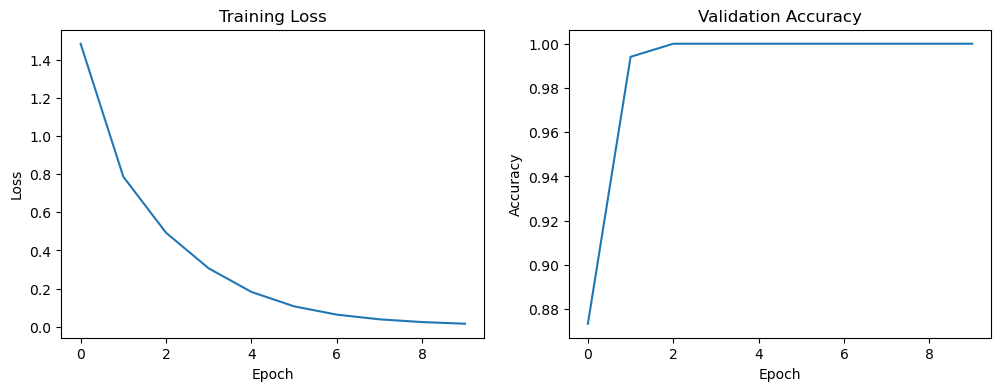

In [89]:
# Визуализация результатов
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()

### Другие модели. Настройки

In [ ]:
#self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
#self.rnn = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.2)